# 07 DBSCAN Hotspot Detection

This notebook identifies traffic crash hotspots using the DBSCAN clustering algorithm.

The original code is preserved. Only Markdown headings and explanations have been added for readability.


## 1. Extract Representative Cluster Centres
Calculate the centermost point for each DBSCAN cluster.


In [ ]:
def get_centermost_point(cluster):
    centroid = (MultiPoint(cluster).centroid.x, MultiPoint(cluster).centroid.y)
    centermost_point = min(cluster, key=lambda point: great_circle(point, centroid).m)
    return tuple(centermost_point)

clusters = [coords[labels == n] for n in range(num_clusters)]
centermost_points = [get_centermost_point(cluster) for cluster in clusters]

# location every high risk point
for i, point in enumerate(centermost_points):
    print(f'Cluster {i}: Centermost point is {point}')

Cluster 0: Centermost point is (-27.45908, 153.01496)
Cluster 1: Centermost point is (-24.87867, 152.34123)
Cluster 2: Centermost point is (-25.42468, 152.75546)
Cluster 3: Centermost point is (-23.8731, 151.23796)
Cluster 4: Centermost point is (-23.36002, 150.52325)
Cluster 5: Centermost point is (-21.15127, 149.15505)
Cluster 6: Centermost point is (-19.29138, 146.76197)
Cluster 7: Centermost point is (-16.91363, 145.72092)


## 2. Cluster Size Distribution
Visualise the number of crashes contained in each detected cluster.


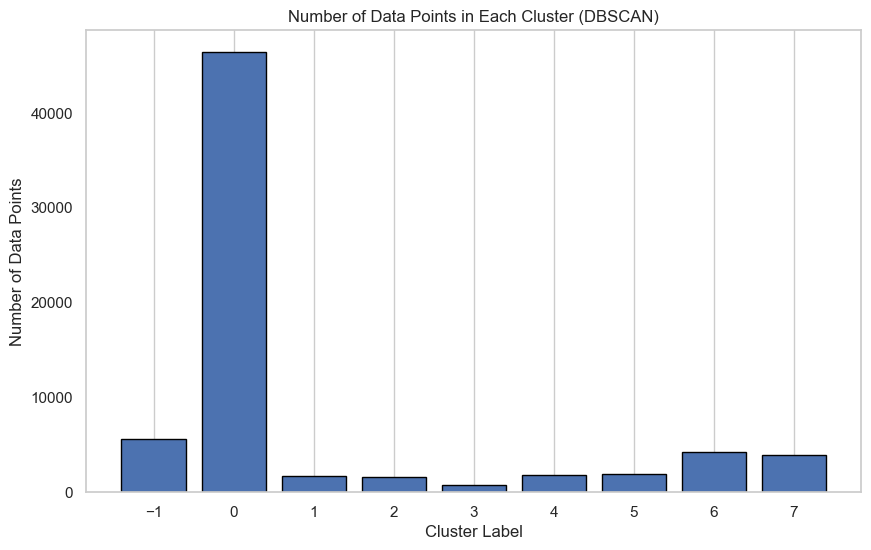

In [ ]:
cluster_counts = df['Cluster'].value_counts().sort_index()

# draw the table
plt.figure(figsize=(10, 6))
plt.bar(cluster_counts.index, cluster_counts.values, edgecolor='black')
plt.xlabel('Cluster Label')
plt.ylabel('Number of Data Points')
plt.title('Number of Data Points in Each Cluster (DBSCAN)')
plt.xticks(cluster_counts.index)  
plt.grid(axis='y')
plt.show()

## 3. Visualise DBSCAN Clusters
Generate the main DBSCAN hotspot visualisation.


In [ ]:
#DBSCAN draw the graph
coords = np.array([
    [latitude, longitude] for latitude, longitude in zip(df['Latitude'], df['Longitude'])
])

db = DBSCAN(eps=0.01, min_samples=10).fit(coords)
labels = db.labels_
#noise point
noise = coords[labels == -1]
print(len(noise))

4282


## 4. Interactive Map Visualisation (Optional)
Generate an interactive map for hotspot exploration.


In [ ]:
# import folium
# import matplotlib.pyplot as plt
# import numpy as np

# map = folium.Map(location=[np.mean(noise[:, 0]), np.mean(noise[:, 1])], zoom_start=12)

# # add noise
# for point in noise:
#     folium.CircleMarker(
#         location=[point[0], point[1]],
#         radius=5,  # set point
#         color='red',   
#         fill=True,
#         fill_color='red',   
#         fill_opacity=0.7  
#     ).add_to(map)

# # html file
# map.save('noise_map.html')


## 5. Selected Features for High-risk Region Analysis
Display the selected features used for hotspot analysis.


In [ ]:
#after future selection
crash_severity_select_column=[]
high_risk_region_select_column=[]
crash_severity_dataset=combined_dataset[crash_severity_select_column]
high_risk_region_dataset=combined_dataset[high_risk_region_select_column]
crash_severity_dataset.to_csv('CrashSeverity_datase.csv', index= False)
high_risk_region_dataset.to_csv('HighRiskRegion_dataset.csv', index= False)


## Summary

DBSCAN is used to identify spatial crash hotspots and visualise high-risk regions. The outputs can support road safety analysis and future resource allocation.
